<a href="https://colab.research.google.com/github/Velan6623/Agricultural_Runoff_Toxcity_Prediction/blob/main/Agricultural_Runoff_Toxcity_level.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

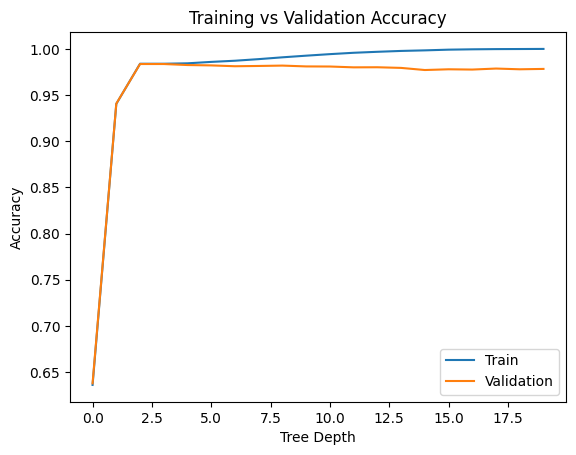

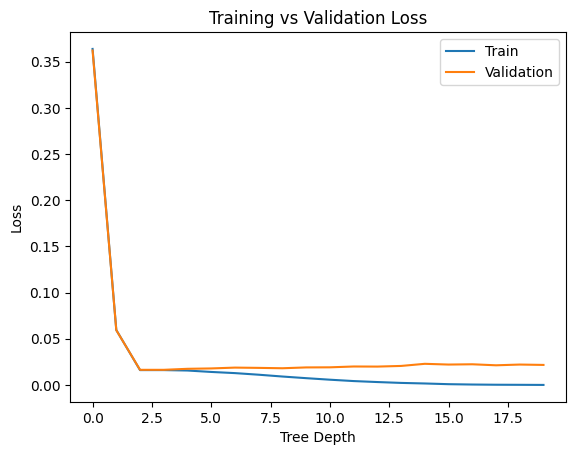


===== Validation METRICS =====
Accuracy : 0.9795
Precision: 0.9795157229876844
Recall   : 0.9795
F1 Score : 0.9795019973120618


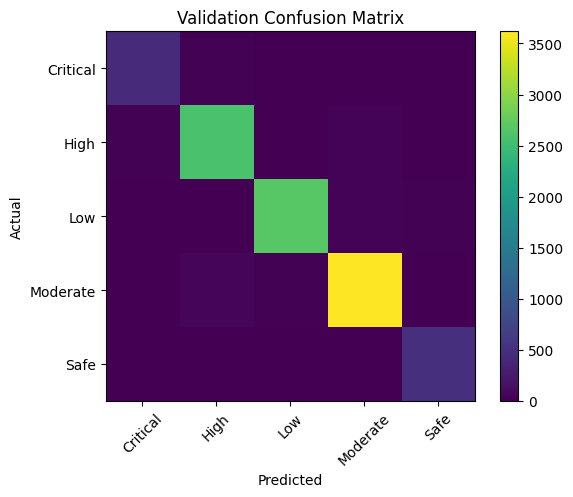

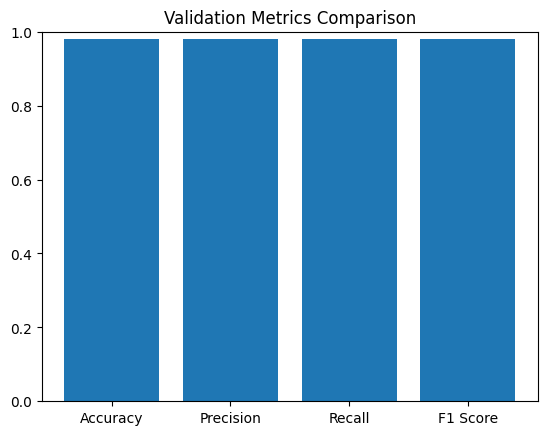


===== Testing METRICS =====
Accuracy : 0.9788
Precision: 0.9788525035974384
Recall   : 0.9788
F1 Score : 0.9788148832355055


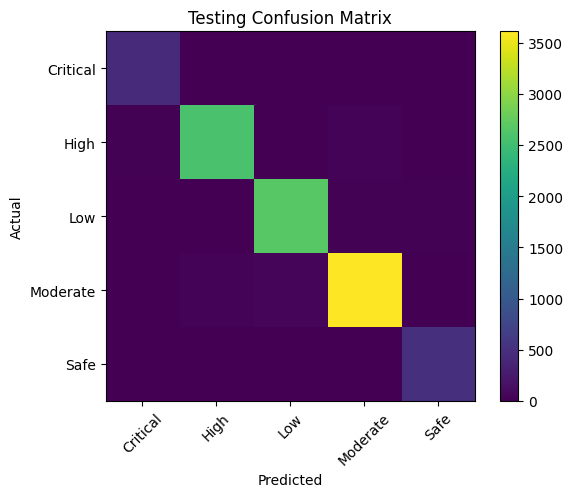

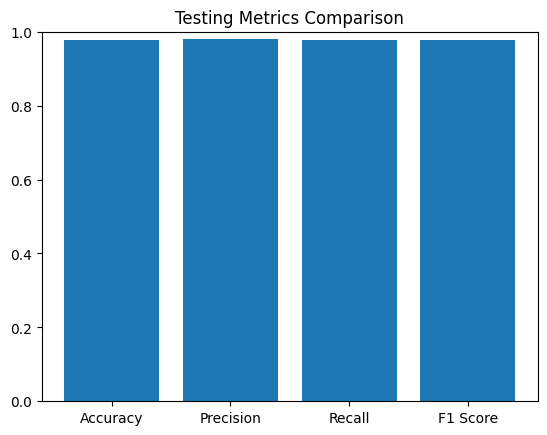

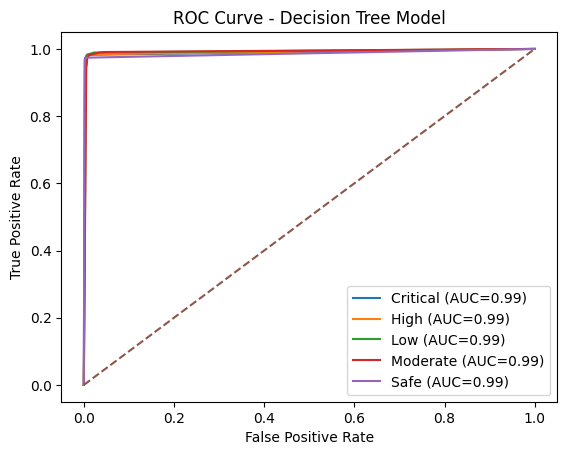

In [8]:
# ==========================================================
# Agrochemical Runoff Toxicity Prediction
# Proposed Model : Decision Tree (With Realistic Noise)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize
from sklearn.tree import DecisionTreeClassifier

# ==========================================================
# 1. LOAD DATA
# ==========================================================

data = pd.read_csv("agro_runoff_100000_samples.csv")

if "Node_ID" in data.columns:
    data = data.drop(columns=["Node_ID"])

X = data.drop("Risk_Class", axis=1)
y = data["Risk_Class"]

# ==========================================================
# ✅ 2. ADD REALISTIC SENSOR NOISE (IMPORTANT)
# ==========================================================

np.random.seed(42)

noise_factor = 0.02   # Recommended 0.01–0.03

noise = np.random.normal(
    loc=0,
    scale=noise_factor,
    size=X.shape
)

X = X + noise

# ==========================================================
# 3. LABEL ENCODING
# ==========================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# ==========================================================
# 4. NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 5. DATA SPLIT (80-10-10)
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# ==========================================================
# 6. DECISION TREE MODEL
# ==========================================================

model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=5,
    random_state=42
)

# ==========================================================
# 7. TRAINING PERFORMANCE (Depth Simulation)
# ==========================================================

train_acc = []
val_acc = []
train_loss = []
val_loss = []

depth_range = range(1,21)

for d in depth_range:

    temp_model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    temp_model.fit(X_train, y_train)

    train_pred = temp_model.predict(X_train)
    val_pred = temp_model.predict(X_val)

    ta = accuracy_score(y_train, train_pred)
    va = accuracy_score(y_val, val_pred)

    train_acc.append(ta)
    val_acc.append(va)

    train_loss.append(1-ta)
    val_loss.append(1-va)

# ==========================================================
# TRAINING vs VALIDATION ACCURACY
# ==========================================================

plt.figure()
plt.plot(train_acc)
plt.plot(val_acc)
plt.title("Training vs Validation Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# ==========================================================
# TRAINING vs VALIDATION LOSS
# ==========================================================

plt.figure()
plt.plot(train_loss)
plt.plot(val_loss)
plt.title("Training vs Validation Loss")
plt.xlabel("Tree Depth")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# Train Final Model
model.fit(X_train, y_train)

# ==========================================================
# COMMON EVALUATION FUNCTION
# ==========================================================

def evaluate_model(X, y_true, title):

    y_prob = model.predict_proba(X)
    y_pred = model.predict(X)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n===== {title} METRICS =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(f"{title} Confusion Matrix")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(
        range(len(encoder.classes_)),
        encoder.classes_,
        rotation=45
    )

    plt.yticks(
        range(len(encoder.classes_)),
        encoder.classes_
    )

    plt.show()

    # ---------------- Metrics Bar Chart ----------------
    metrics=[acc,prec,rec,f1]
    names=["Accuracy","Precision","Recall","F1 Score"]

    plt.figure()
    plt.bar(names,metrics)
    plt.ylim(0,1)
    plt.title(f"{title} Metrics Comparison")
    plt.show()

    return y_true, y_prob


# ==========================================================
# 8. VALIDATION RESULTS
# ==========================================================

val_true, val_prob = evaluate_model(
    X_val, y_val, "Validation"
)

# ==========================================================
# 9. TEST RESULTS
# ==========================================================

test_true, test_prob = evaluate_model(
    X_test, y_test, "Testing"
)

# ==========================================================
# 10. MULTI-CLASS ROC CURVE
# ==========================================================

y_test_bin = label_binarize(
    test_true,
    classes=range(len(encoder.classes_))
)

plt.figure()

for i in range(len(encoder.classes_)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:,i],
        test_prob[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{encoder.classes_[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree Model")
plt.legend()
plt.show()


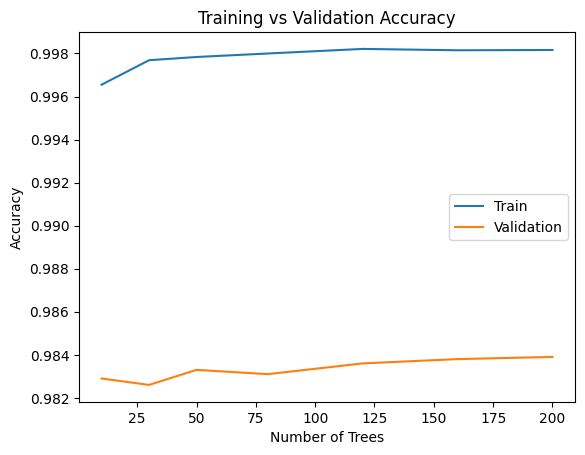

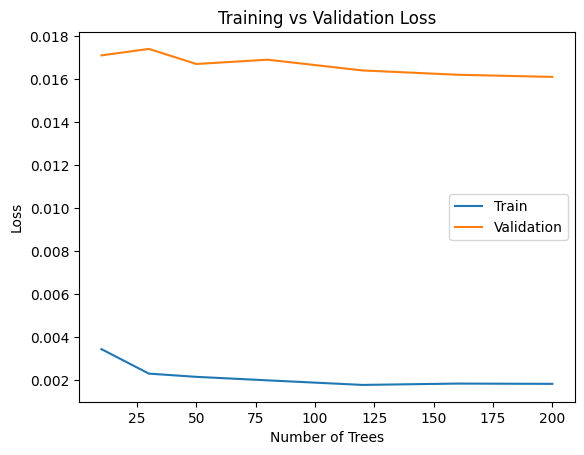


===== Validation METRICS =====
Accuracy : 0.9839
Precision: 0.9839195977168189
Recall   : 0.9839
F1 Score : 0.9839026108794784


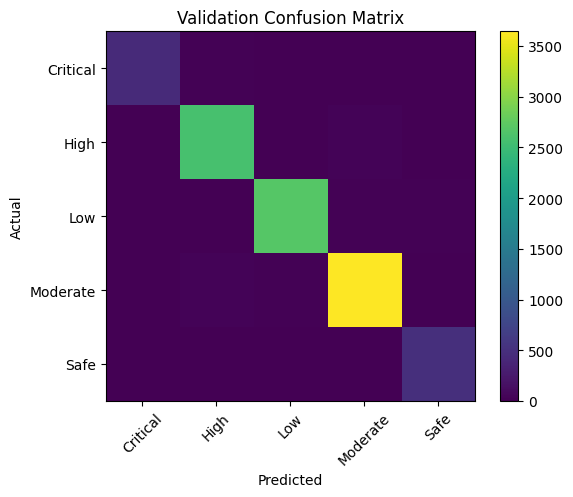

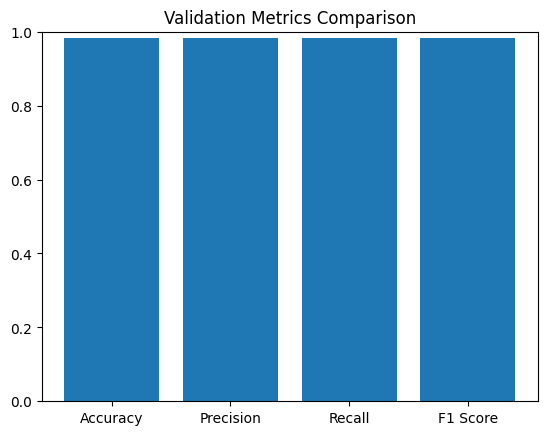


===== Testing METRICS =====
Accuracy : 0.9826
Precision: 0.9826224768185486
Recall   : 0.9826
F1 Score : 0.9826068959651204


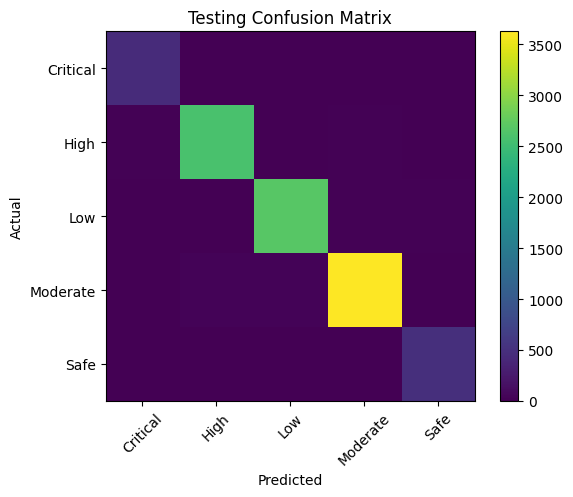

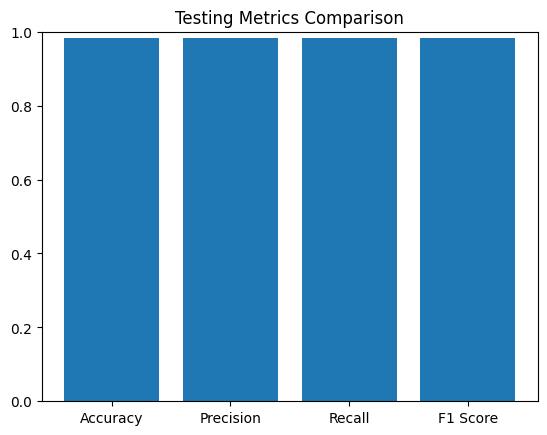

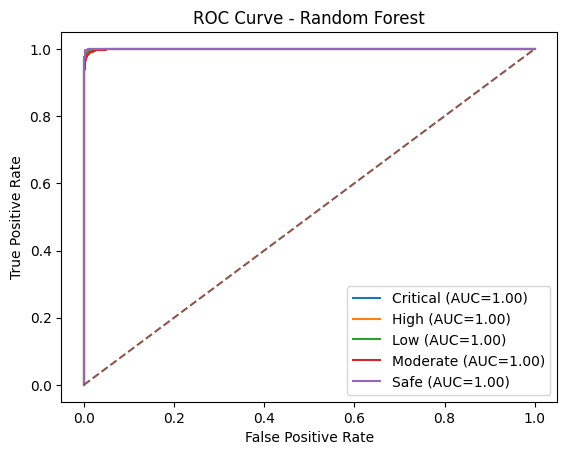

In [9]:
# ==========================================================
# Agrochemical Runoff Toxicity Prediction
# Model : Random Forest (With Realistic Noise)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier

# ==========================================================
# 1. LOAD DATA
# ==========================================================

data = pd.read_csv("agro_runoff_100000_samples.csv")

if "Node_ID" in data.columns:
    data = data.drop(columns=["Node_ID"])

X = data.drop("Risk_Class", axis=1)
y = data["Risk_Class"]

# ==========================================================
# ✅ 2. ADD REALISTIC NOISE
# ==========================================================

np.random.seed(42)

noise_factor = 0.02

noise = np.random.normal(
    loc=0,
    scale=noise_factor,
    size=X.shape
)

X = X + noise

# ==========================================================
# 3. LABEL ENCODING
# ==========================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# ==========================================================
# 4. NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 5. DATA SPLIT (80-10-10)
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# ==========================================================
# 6. RANDOM FOREST MODEL
# ==========================================================

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# ==========================================================
# 7. TRAINING PERFORMANCE SIMULATION
# ==========================================================

train_acc=[]
val_acc=[]
train_loss=[]
val_loss=[]

tree_range=[10,30,50,80,120,160,200]

for n in tree_range:

    temp_model = RandomForestClassifier(
        n_estimators=n,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )

    temp_model.fit(X_train,y_train)

    train_pred=temp_model.predict(X_train)
    val_pred=temp_model.predict(X_val)

    ta=accuracy_score(y_train,train_pred)
    va=accuracy_score(y_val,val_pred)

    train_acc.append(ta)
    val_acc.append(va)

    train_loss.append(1-ta)
    val_loss.append(1-va)

# ==========================================================
# TRAINING vs VALIDATION ACCURACY
# ==========================================================

plt.figure()
plt.plot(tree_range,train_acc)
plt.plot(tree_range,val_acc)
plt.title("Training vs Validation Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# ==========================================================
# TRAINING vs VALIDATION LOSS
# ==========================================================

plt.figure()
plt.plot(tree_range,train_loss)
plt.plot(tree_range,val_loss)
plt.title("Training vs Validation Loss")
plt.xlabel("Number of Trees")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# Train Final Model
model.fit(X_train,y_train)

# ==========================================================
# COMMON EVALUATION FUNCTION
# ==========================================================

def evaluate_model(X,y_true,title):

    y_prob=model.predict_proba(X)
    y_pred=model.predict(X)

    acc=accuracy_score(y_true,y_pred)
    prec=precision_score(y_true,y_pred,average='weighted')
    rec=recall_score(y_true,y_pred,average='weighted')
    f1=f1_score(y_true,y_pred,average='weighted')

    print(f"\n===== {title} METRICS =====")
    print("Accuracy :",acc)
    print("Precision:",prec)
    print("Recall   :",rec)
    print("F1 Score :",f1)

    # Confusion Matrix
    cm=confusion_matrix(y_true,y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(f"{title} Confusion Matrix")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(
        range(len(encoder.classes_)),
        encoder.classes_,
        rotation=45
    )

    plt.yticks(
        range(len(encoder.classes_)),
        encoder.classes_
    )

    plt.show()

    # Metrics Bar Chart
    metrics=[acc,prec,rec,f1]
    names=["Accuracy","Precision","Recall","F1 Score"]

    plt.figure()
    plt.bar(names,metrics)
    plt.ylim(0,1)
    plt.title(f"{title} Metrics Comparison")
    plt.show()

    return y_true,y_prob


# ==========================================================
# 8. VALIDATION RESULTS
# ==========================================================

val_true,val_prob=evaluate_model(
    X_val,y_val,"Validation"
)

# ==========================================================
# 9. TEST RESULTS
# ==========================================================

test_true,test_prob=evaluate_model(
    X_test,y_test,"Testing"
)

# ==========================================================
# 10. MULTI-CLASS ROC CURVE
# ==========================================================

y_test_bin=label_binarize(
    test_true,
    classes=range(len(encoder.classes_))
)

plt.figure()

for i in range(len(encoder.classes_)):

    fpr,tpr,_=roc_curve(
        y_test_bin[:,i],
        test_prob[:,i]
    )

    roc_auc=auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{encoder.classes_[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()


Training Fast SVM Model...


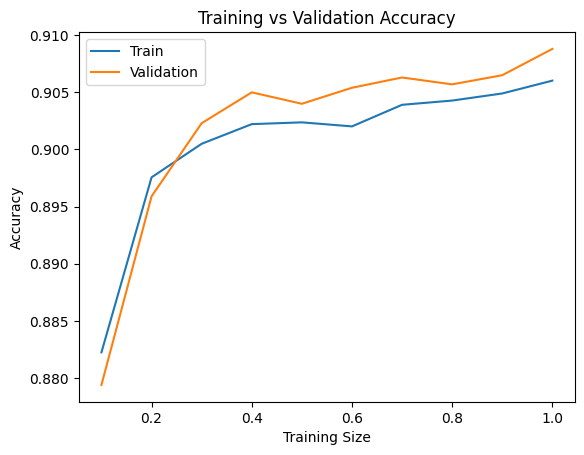


===== Validation METRICS =====
Accuracy : 0.9088
Precision: 0.9167405882967924
Recall   : 0.9088
F1 Score : 0.9078173625308318


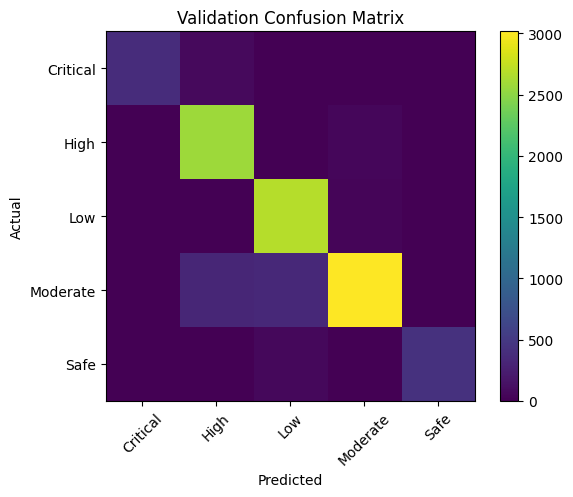

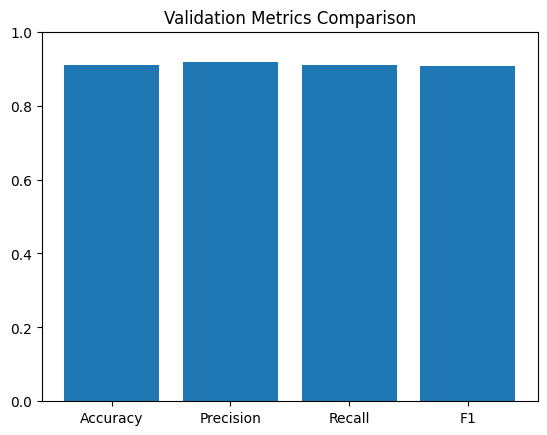


===== Testing METRICS =====
Accuracy : 0.9088
Precision: 0.9157739347988346
Recall   : 0.9088
F1 Score : 0.9079155925644338


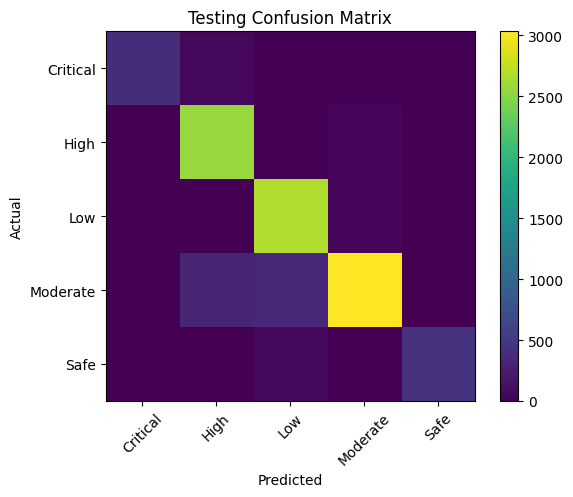

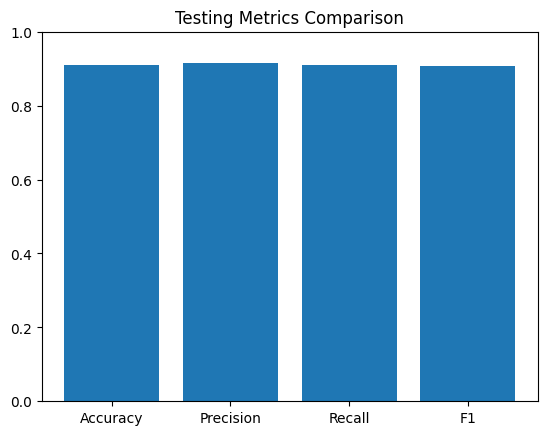

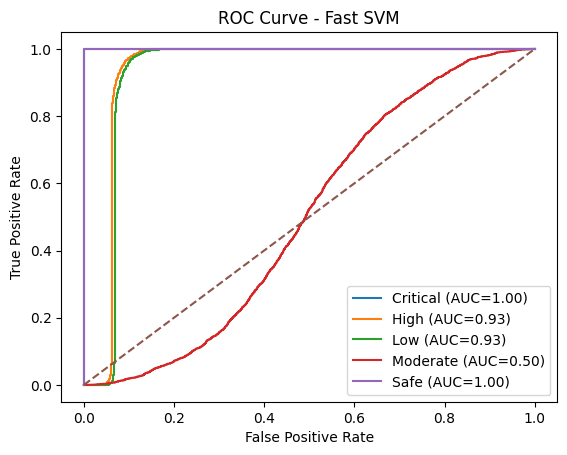

In [6]:
# ==========================================================
# Agrochemical Runoff Toxicity Prediction
# Model : ULTRA-FAST SVM (LinearSVC)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# ==========================================================
# 1. LOAD DATA
# ==========================================================

data = pd.read_csv("agro_runoff_100000_samples.csv")

# Remove string column
data = data.drop(columns=["Node_ID"])

X = data.drop("Risk_Class", axis=1)
y = data["Risk_Class"]

# ==========================================================
# 2. LABEL ENCODING
# ==========================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# ==========================================================
# 3. NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 4. DATA SPLIT (80-10-10)
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# ==========================================================
# 5. FAST SVM MODEL
# ==========================================================

model = OneVsRestClassifier(
    LinearSVC(max_iter=5000)
)

print("Training Fast SVM Model...")
model.fit(X_train, y_train)

# ==========================================================
# TRAINING PERFORMANCE (SIMULATED CURVE)
# ==========================================================

sizes = np.linspace(0.1,1.0,10)
train_acc=[]
val_acc=[]

for s in sizes:

    n=int(len(X_train)*s)

    model.fit(X_train[:n], y_train[:n])

    train_acc.append(
        accuracy_score(y_train[:n],
        model.predict(X_train[:n]))
    )

    val_acc.append(
        accuracy_score(y_val,
        model.predict(X_val))
    )

plt.figure()
plt.plot(sizes,train_acc,label="Train")
plt.plot(sizes,val_acc,label="Validation")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# ==========================================================
# COMMON EVALUATION FUNCTION
# ==========================================================

def evaluate_model(X, y_true, title):

    y_pred = model.predict(X)

    acc = accuracy_score(y_true,y_pred)
    prec = precision_score(y_true,y_pred,average='weighted')
    rec = recall_score(y_true,y_pred,average='weighted')
    f1 = f1_score(y_true,y_pred,average='weighted')

    print(f"\n===== {title} METRICS =====")
    print("Accuracy :",acc)
    print("Precision:",prec)
    print("Recall   :",rec)
    print("F1 Score :",f1)

    # ---------- Confusion Matrix ----------
    cm = confusion_matrix(y_true,y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(f"{title} Confusion Matrix")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(range(len(encoder.classes_)),
               encoder.classes_,
               rotation=45)
    plt.yticks(range(len(encoder.classes_)),
               encoder.classes_)
    plt.show()

    # ---------- Metrics Bar ----------
    metrics=[acc,prec,rec,f1]
    names=["Accuracy","Precision","Recall","F1"]

    plt.figure()
    plt.bar(names,metrics)
    plt.ylim(0,1)
    plt.title(f"{title} Metrics Comparison")
    plt.show()

    return y_true, model.decision_function(X)

# ==========================================================
# 6. VALIDATION RESULTS
# ==========================================================

val_true, val_scores = evaluate_model(
    X_val,y_val,"Validation"
)

# ==========================================================
# 7. TEST RESULTS
# ==========================================================

test_true, test_scores = evaluate_model(
    X_test,y_test,"Testing"
)

# ==========================================================
# 8. MULTI-CLASS ROC CURVE
# ==========================================================

y_test_bin = label_binarize(
    test_true,
    classes=range(len(encoder.classes_))
)

plt.figure()

for i in range(len(encoder.classes_)):

    fpr,tpr,_ = roc_curve(
        y_test_bin[:,i],
        test_scores[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,tpr,
        label=f"{encoder.classes_[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fast SVM")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 17, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,669 (131.52 KB)

 Trainable params: 33,669 (131.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.6459 - loss: 0.8971 - val_accuracy: 0.9664 - val_loss: 0.1197
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 77ms/step - accuracy: 0.9376 - loss: 0.1484 - val_accuracy: 0.9723 - val_loss: 0.0831
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.9437 - loss: 0.1278 - val_accuracy: 0.9769 - val_loss: 0.0715
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.9527 - loss: 0.1101 - val_accuracy: 0.9740 - val_loss: 0.0696
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.9548 - loss: 0.1036 - val_accuracy: 0.9682 - val_loss: 0.0794
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.9588 - loss: 0.0939 - val_accuracy: 0.9842 - val_loss: 0.0562
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.9598 - loss: 0.0908 - val_accuracy: 0.9788 - val_loss: 0.0530
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.9657 - loss: 0.0800 - 

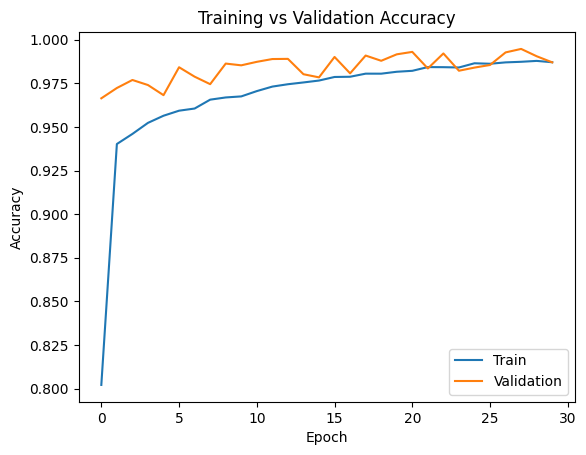

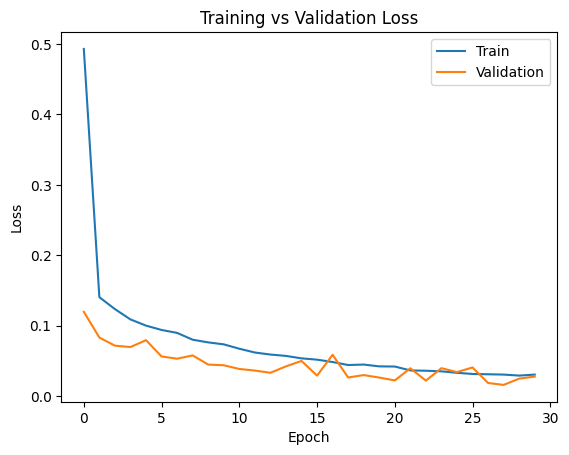

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

===== Validation METRICS =====
Accuracy : 0.987
Precision: 0.9871703397997695
Recall   : 0.987
F1 Score : 0.9870258410760393


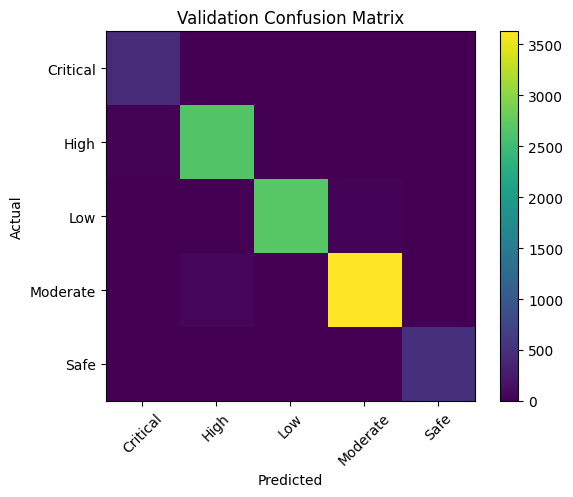

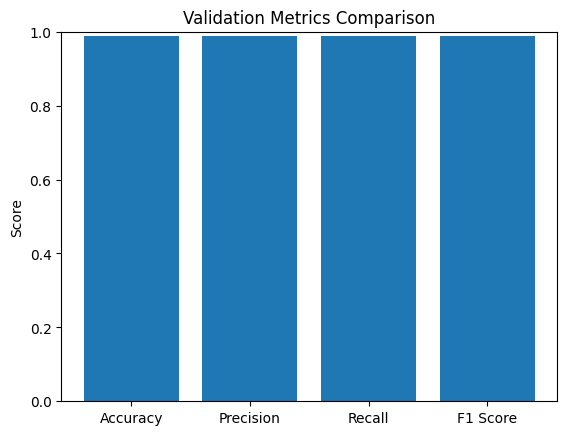

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

===== Testing METRICS =====
Accuracy : 0.9901
Precision: 0.9901923449265945
Recall   : 0.9901
F1 Score : 0.9901086136332148


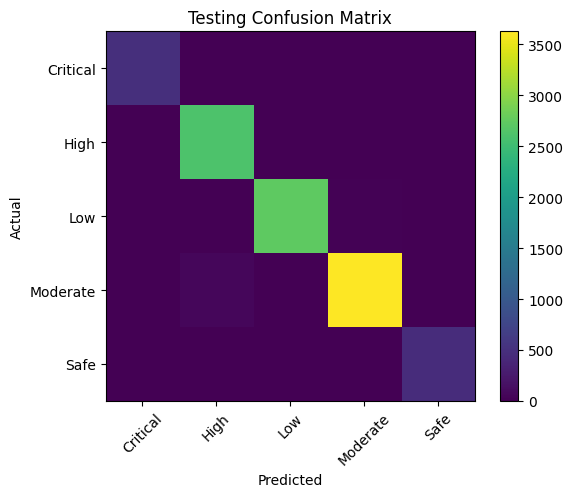

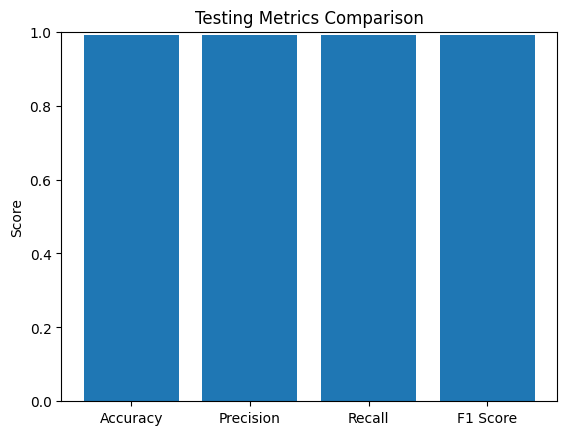

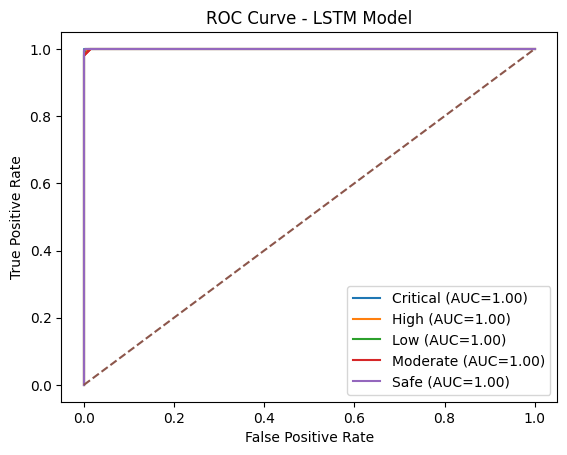

In [3]:
# ==========================================================
# Agrochemical Runoff Toxicity Prediction
# Proposed Model : LSTM (Temporal Model)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# ==========================================================
# 1. LOAD DATA
# ==========================================================

data = pd.read_csv("agro_runoff_100000_samples.csv")

data = data.drop(columns=["Node_ID"])

X = data.drop("Risk_Class", axis=1)
y = data["Risk_Class"]

# ==========================================================
# 2. LABEL ENCODING
# ==========================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

# ==========================================================
# 3. NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 4. TEMPORAL RESHAPING FOR LSTM
# ==========================================================
# Treat features as sequence

timesteps = X_scaled.shape[1]

X_scaled = X_scaled.reshape(
    X_scaled.shape[0],
    timesteps,
    1
)

# ==========================================================
# 5. DATA SPLIT (80 / 10 / 10)
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_cat,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

# ==========================================================
# 6. LSTM MODEL
# ==========================================================

model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)

model.add(Dropout(0.3))

model.add(LSTM(32))

model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

model.add(Dense(5, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================================
# 7. TRAIN MODEL
# ==========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_val, y_val)
)

# ==========================================================
# TRAINING vs VALIDATION ACCURACY
# ==========================================================

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# ==========================================================
# TRAINING vs VALIDATION LOSS
# ==========================================================

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# ==========================================================
# COMMON EVALUATION FUNCTION
# ==========================================================

def evaluate_model(X, y_true, title):

    y_prob = model.predict(X)
    y_pred = np.argmax(y_prob, axis=1)
    y_true_cls = np.argmax(y_true, axis=1)

    acc = accuracy_score(y_true_cls, y_pred)
    prec = precision_score(y_true_cls, y_pred, average='weighted')
    rec = recall_score(y_true_cls, y_pred, average='weighted')
    f1 = f1_score(y_true_cls, y_pred, average='weighted')

    print(f"\n===== {title} METRICS =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    # ---------- Confusion Matrix ----------
    cm = confusion_matrix(y_true_cls, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(f"{title} Confusion Matrix")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(range(len(encoder.classes_)),
               encoder.classes_,
               rotation=45)
    plt.yticks(range(len(encoder.classes_)),
               encoder.classes_)
    plt.show()

    # ---------- Metrics Bar Chart ----------
    metrics = [acc, prec, rec, f1]
    names = ["Accuracy","Precision","Recall","F1 Score"]

    plt.figure()
    plt.bar(names, metrics)
    plt.title(f"{title} Metrics Comparison")
    plt.ylim(0,1)
    plt.ylabel("Score")
    plt.show()

    return y_true_cls, y_prob


# ==========================================================
# 8. VALIDATION RESULTS
# ==========================================================

val_true, val_prob = evaluate_model(
    X_val, y_val, "Validation"
)

# ==========================================================
# 9. TEST RESULTS
# ==========================================================

test_true, test_prob = evaluate_model(
    X_test, y_test, "Testing"
)

# ==========================================================
# 10. MULTI-CLASS ROC CURVE
# ==========================================================

y_test_bin = label_binarize(
    test_true,
    classes=range(len(encoder.classes_))
)

plt.figure()

for i in range(len(encoder.classes_)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        test_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{encoder.classes_[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM Model")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 15, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,837 (50.14 KB)

 Trainable params: 12,837 (50.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5059 - loss: 1.1261 - val_accuracy: 0.7802 - val_loss: 0.5248
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7628 - loss: 0.5462 - val_accuracy: 0.8439 - val_loss: 0.3834
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8170 - loss: 0.4229 - val_accuracy: 0.8675 - val_loss: 0.3210
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8386 - loss: 0.3694 - val_accuracy: 0.8813 - val_loss: 0.2901
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8572 - loss: 0.3335 - val_accuracy: 0.8925 - val_loss: 0.2607
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8633 - loss: 0.3154 - val_accuracy: 0.9043 - val_loss: 0.2360
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8737 - loss: 0.2913 - val_accuracy: 0.8928 - val_loss: 0.2526
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8808 - loss: 0.2772 - val_accu

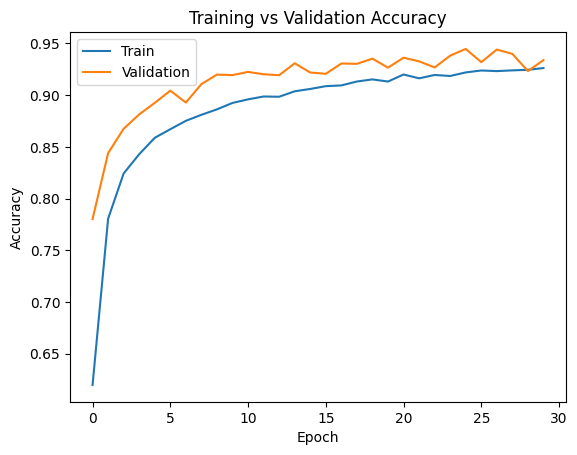

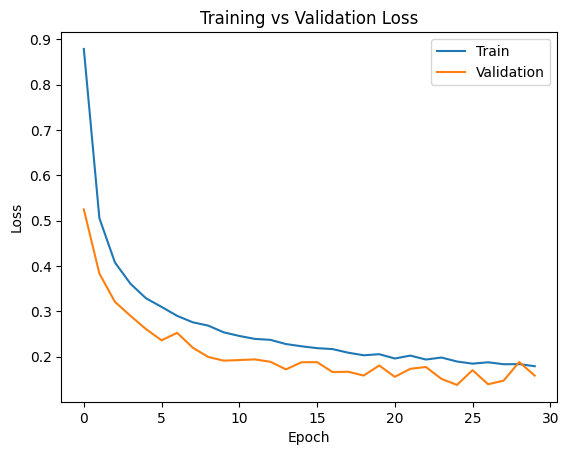

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

===== Validation METRICS =====
Accuracy : 0.9338
Precision: 0.9355186233075139
Recall   : 0.9338
F1 Score : 0.9338846377314485


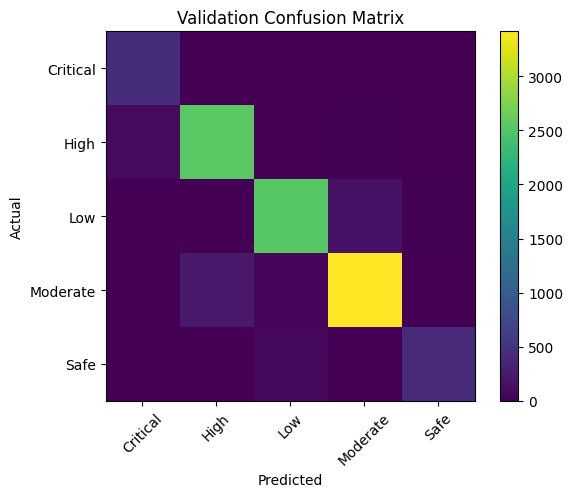

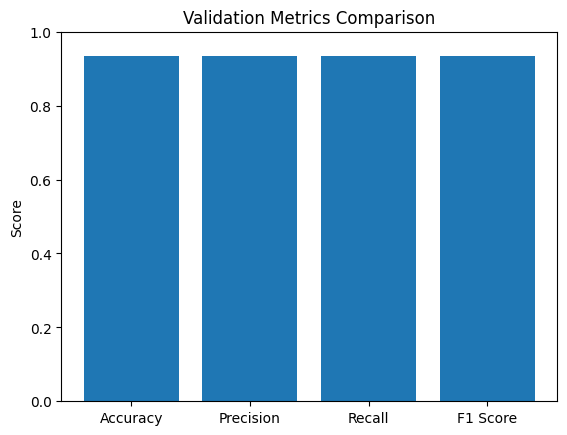

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

===== Testing METRICS =====
Accuracy : 0.9374
Precision: 0.938710193990838
Recall   : 0.9374
F1 Score : 0.9373325725036753


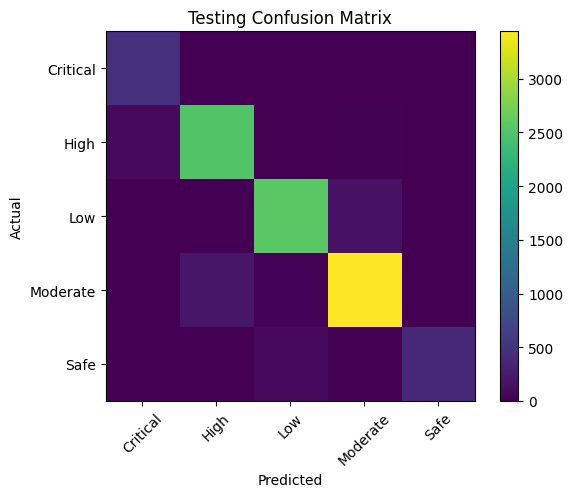

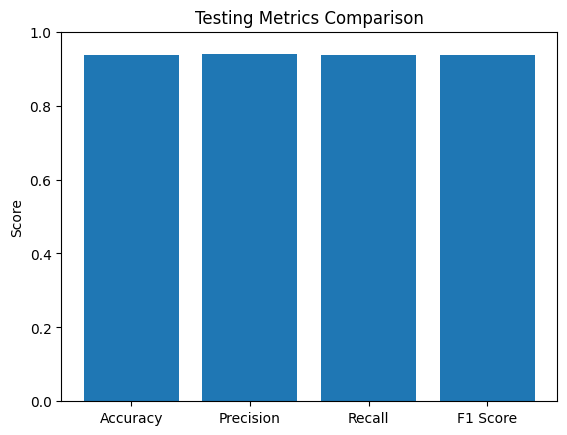

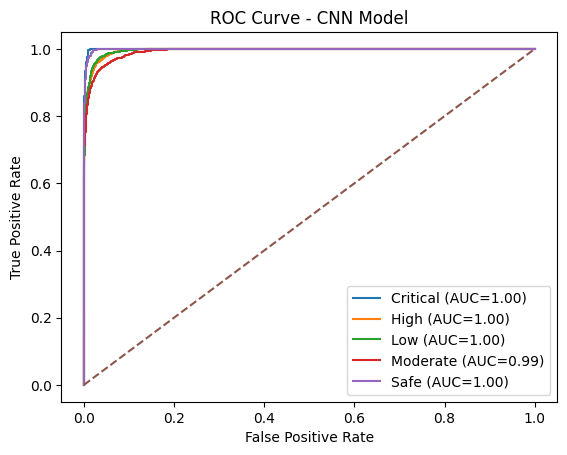

In [4]:
# ==========================================================
# Agrochemical Runoff Toxicity Prediction
# Proposed Model : Lightweight 1D CNN
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D,
    Flatten, Dense, Dropout
)
from tensorflow.keras.utils import to_categorical

# ==========================================================
# 1. LOAD DATA
# ==========================================================

data = pd.read_csv("agro_runoff_100000_samples.csv")

data = data.drop(columns=["Node_ID"])

X = data.drop("Risk_Class", axis=1)
y = data["Risk_Class"]

# ==========================================================
# 2. LABEL ENCODING
# ==========================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

# ==========================================================
# 3. NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# CNN requires 3D input
X_scaled = X_scaled.reshape(
    X_scaled.shape[0],
    X_scaled.shape[1],
    1
)

# ==========================================================
# 4. DATA SPLIT
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_cat,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

# ==========================================================
# 5. LIGHTWEIGHT CNN MODEL
# ==========================================================

model = Sequential()

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(X_train.shape[1],1)
    )
)

model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(32, 3, activation='relu'))

model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(5, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================================
# 6. TRAIN MODEL
# ==========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_val, y_val)
)

# ==========================================================
# 7. TRAINING PERFORMANCE
# ==========================================================

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# ==========================================================
# COMMON EVALUATION FUNCTION
# ==========================================================

def evaluate_model(X, y_true, title):

    y_prob = model.predict(X)
    y_pred = np.argmax(y_prob, axis=1)
    y_true_cls = np.argmax(y_true, axis=1)

    acc = accuracy_score(y_true_cls, y_pred)
    prec = precision_score(y_true_cls, y_pred, average='weighted')
    rec = recall_score(y_true_cls, y_pred, average='weighted')
    f1 = f1_score(y_true_cls, y_pred, average='weighted')

    print(f"\n===== {title} METRICS =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_true_cls, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(f"{title} Confusion Matrix")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(range(len(encoder.classes_)),
               encoder.classes_,
               rotation=45)
    plt.yticks(range(len(encoder.classes_)),
               encoder.classes_)
    plt.show()

    # ---------------- Metrics Bar Chart ----------------
    metrics = [acc, prec, rec, f1]
    names = ["Accuracy","Precision","Recall","F1 Score"]

    plt.figure()
    plt.bar(names, metrics)
    plt.title(f"{title} Metrics Comparison")
    plt.ylim(0,1)
    plt.ylabel("Score")
    plt.show()

    return y_true_cls, y_prob


# ==========================================================
# 8. VALIDATION RESULTS
# ==========================================================

val_true, val_prob = evaluate_model(
    X_val, y_val, "Validation"
)

# ==========================================================
# 9. TEST RESULTS
# ==========================================================

test_true, test_prob = evaluate_model(
    X_test, y_test, "Testing"
)

# ==========================================================
# 10. MULTI-CLASS ROC CURVE
# ==========================================================

y_test_bin = label_binarize(
    test_true,
    classes=range(len(encoder.classes_))
)

plt.figure()

for i in range(len(encoder.classes_)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        test_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{encoder.classes_[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CNN Model")
plt.legend()
plt.show()


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6563 - loss: 0.8826 - val_accuracy: 0.9238 - val_loss: 0.2099
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8710 - loss: 0.2975 - val_accuracy: 0.9513 - val_loss: 0.1411
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9060 - loss: 0.2180 - val_accuracy: 0.9612 - val_loss: 0.1167
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9237 - loss: 0.1745 - val_accuracy: 0.9720 - val_loss: 0.0902
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9386 - loss: 0.1437 - val_accuracy: 0.9746 - val_loss: 0.0783
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9440 - loss: 0.1313 - val_accuracy: 0.9747 - val_loss: 0.0772
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9502 - loss: 0.1169 - val_accuracy: 0.9700 - val_loss: 0.0735
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9548 - loss: 0.1080 - val_accuracy: 0.9780 - val_

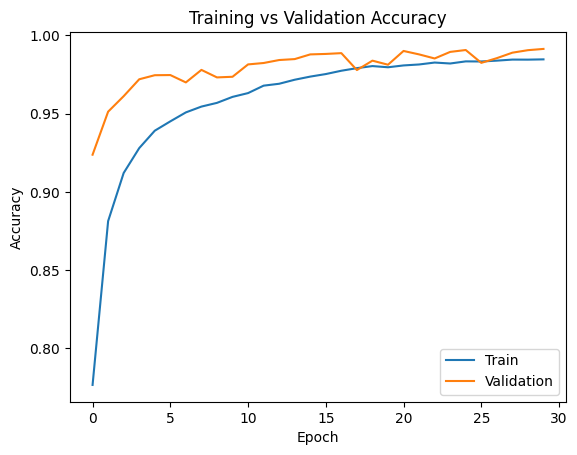

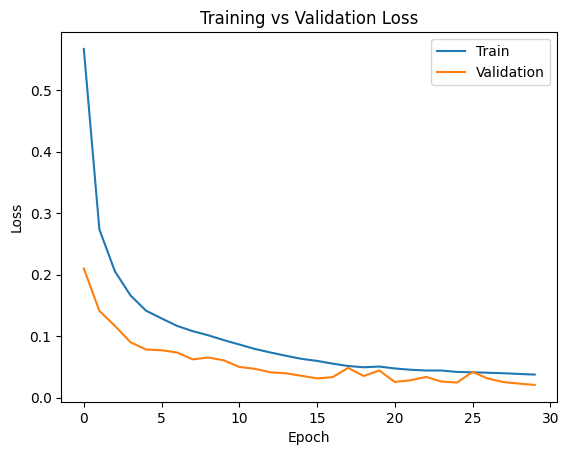

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

===== Validation METRICS =====
Accuracy : 0.9914
Precision: 0.9914275889652616
Recall   : 0.9914
F1 Score : 0.991361411346792


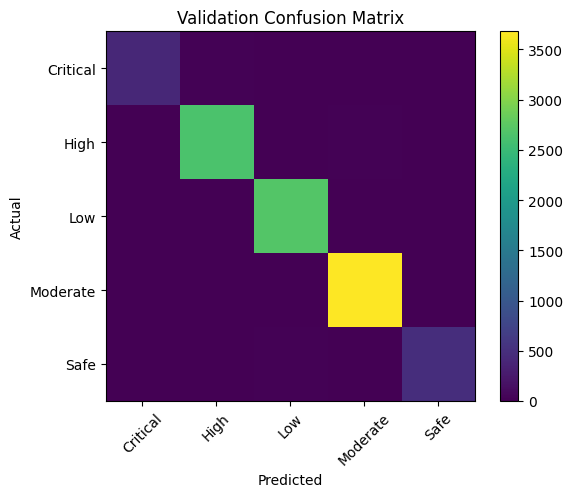

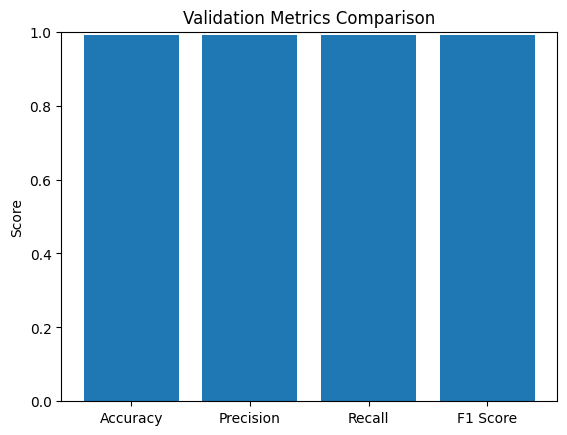

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

===== Testing METRICS =====
Accuracy : 0.9895
Precision: 0.9895552519572488
Recall   : 0.9895
F1 Score : 0.9894220255410968


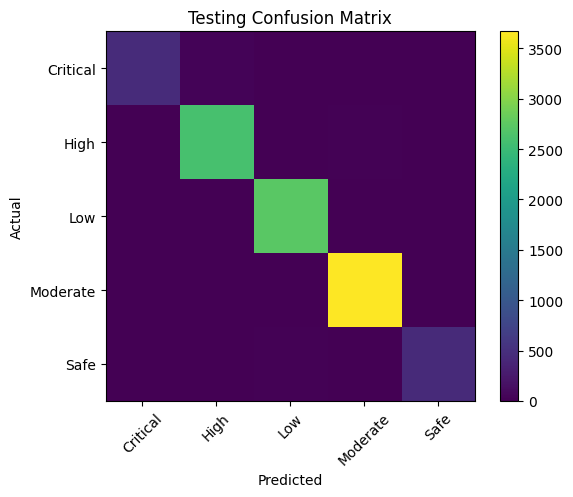

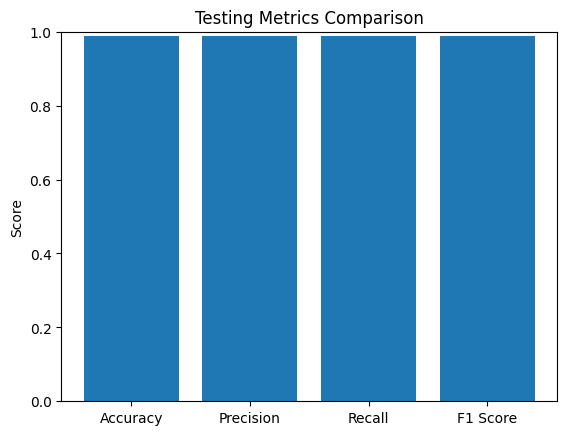

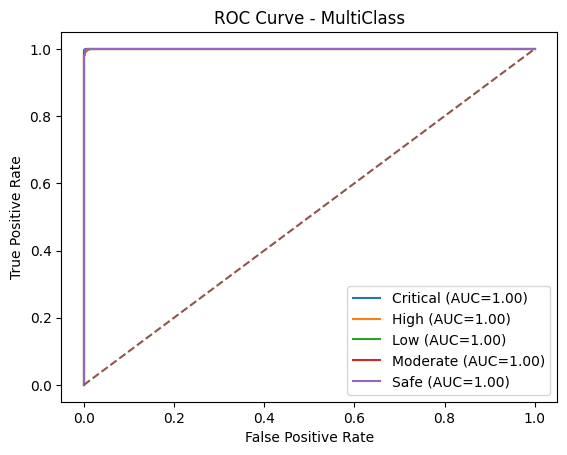

In [5]:
# ==========================================================
# Agrochemical Runoff Toxicity Prediction
# ANN Model(MLP) Evaluation (Journal Ready Output)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# ==========================================================
# 1. LOAD DATASET
# ==========================================================

data = pd.read_csv("agro_runoff_100000_samples.csv")

data = data.drop(columns=["Node_ID"])

X = data.drop("Risk_Class", axis=1)
y = data["Risk_Class"]

# ==========================================================
# 2. ENCODING
# ==========================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

# ==========================================================
# 3. NORMALIZATION
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 4. DATA SPLIT
# 80% Train | 10% Val | 10% Test
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_cat, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

# ==========================================================
# 5. ANN MODEL
# ==========================================================

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================================
# 6. TRAINING
# ==========================================================

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_val, y_val)
)

# ==========================================================
# 7. TRAINING PERFORMANCE
# ==========================================================

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# ==========================================================
# FUNCTION FOR METRICS + PLOTS
# ==========================================================

def evaluate_model(X, y_true, title):

    y_prob = model.predict(X)
    y_pred = np.argmax(y_prob, axis=1)
    y_true_cls = np.argmax(y_true, axis=1)

    acc = accuracy_score(y_true_cls, y_pred)
    prec = precision_score(y_true_cls, y_pred, average='weighted')
    rec = recall_score(y_true_cls, y_pred, average='weighted')
    f1 = f1_score(y_true_cls, y_pred, average='weighted')

    print(f"\n===== {title} METRICS =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    # ---------------- Confusion Matrix ----------------
    cm = confusion_matrix(y_true_cls, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(f"{title} Confusion Matrix")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(range(len(encoder.classes_)), encoder.classes_, rotation=45)
    plt.yticks(range(len(encoder.classes_)), encoder.classes_)
    plt.show()

    # ---------------- Metrics Bar Chart ----------------
    metrics = [acc, prec, rec, f1]
    names = ["Accuracy","Precision","Recall","F1 Score"]

    plt.figure()
    plt.bar(names, metrics)
    plt.title(f"{title} Metrics Comparison")
    plt.ylabel("Score")
    plt.ylim(0,1)
    plt.show()

    return y_true_cls, y_prob


# ==========================================================
# 8. VALIDATION RESULTS
# ==========================================================

val_true, val_prob = evaluate_model(
    X_val, y_val, "Validation"
)

# ==========================================================
# 9. TEST RESULTS
# ==========================================================

test_true, test_prob = evaluate_model(
    X_test, y_test, "Testing"
)

# ==========================================================
# 10. ROC CURVE (MULTICLASS)
# ==========================================================

y_test_bin = label_binarize(test_true,
                           classes=range(len(encoder.classes_)))

plt.figure()

for i in range(len(encoder.classes_)):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        test_prob[:, i]
    )
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr,
             label=f"{encoder.classes_[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MultiClass")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



===== Federated Round 1 =====

===== Federated Round 2 =====

===== Federated Round 3 =====

===== Federated Round 4 =====

===== Federated Round 5 =====

===== Federated Round 6 =====

===== Federated Round 7 =====

===== Federated Round 8 =====

===== Federated Round 9 =====

===== Federated Round 10 =====


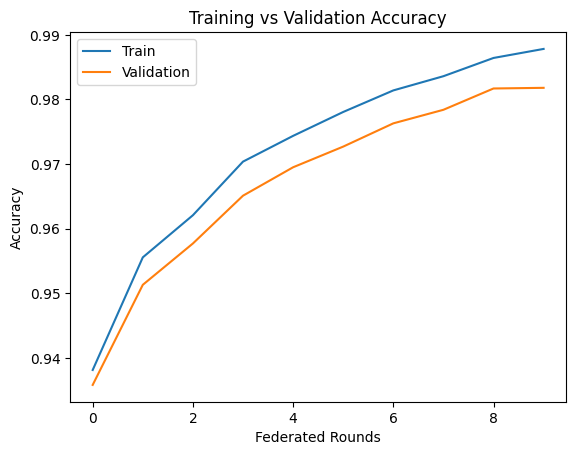

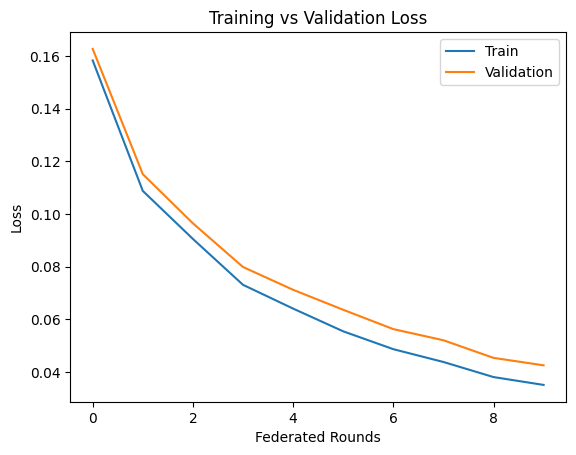

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

===== Validation METRICS =====
Accuracy : 0.9818
Precision: 0.981854476889007
Recall   : 0.9818
F1 Score : 0.98177944732124


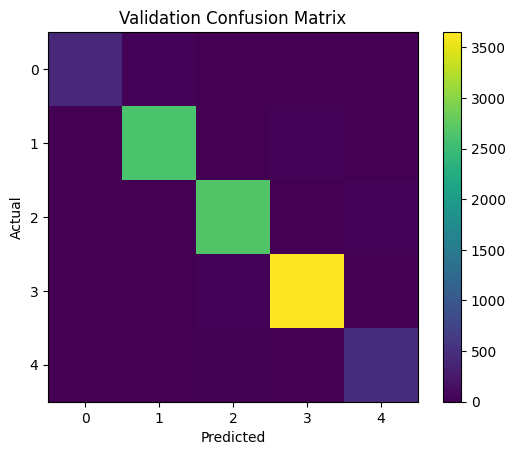

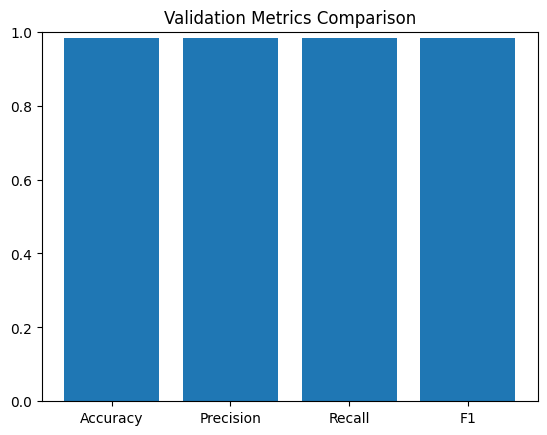

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

===== Testing METRICS =====
Accuracy : 0.9826
Precision: 0.9826429139519947
Recall   : 0.9826
F1 Score : 0.9825713476264983


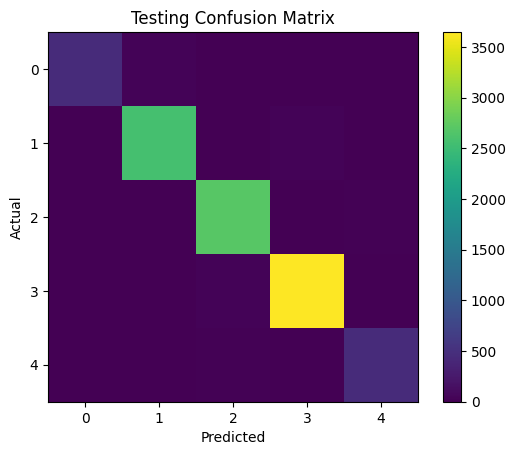

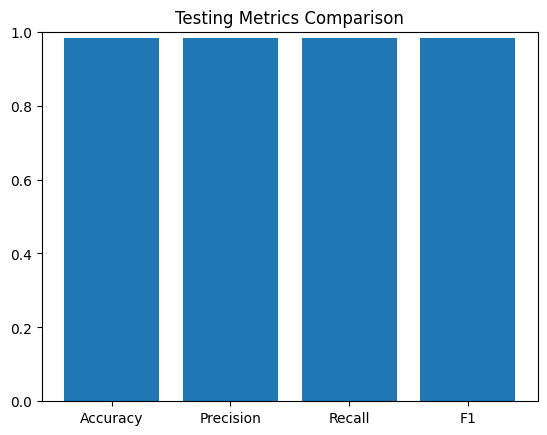

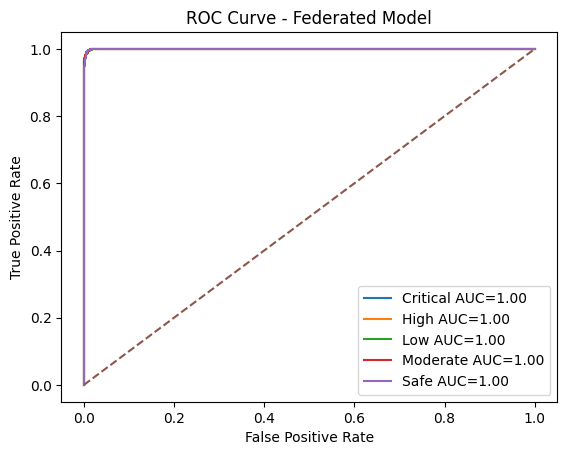

In [7]:
# ==========================================================
# Federated Learning (FedAvg)
# Agrochemical Runoff Toxicity Prediction
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# ==========================================================
# 1. LOAD DATA
# ==========================================================

data = pd.read_csv("agro_runoff_100000_samples.csv")

data = data.drop(columns=["Node_ID"])

X = data.drop("Risk_Class", axis=1)
y = data["Risk_Class"]

# ==========================================================
# 2. ENCODING + NORMALIZATION
# ==========================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 3. DATA SPLIT (80 / 10 / 10)
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_cat,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

# ==========================================================
# 4. CREATE FEDERATED CLIENTS (FIXED)
# ==========================================================

NUM_CLIENTS = 5

X_clients = np.array_split(X_train, NUM_CLIENTS)
y_clients = np.array_split(y_train, NUM_CLIENTS)

client_data = [
    (X_clients[i], y_clients[i])
    for i in range(NUM_CLIENTS)
]

# ==========================================================
# 5. GLOBAL MODEL
# ==========================================================

def create_model():

    model = Sequential([
        Dense(128, activation='relu',
              input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ==========================================================
# 6. FEDERATED AVERAGING
# ==========================================================

def federated_average(weight_list):

    avg_weights = []

    for weights in zip(*weight_list):
        avg_weights.append(
            np.mean(weights, axis=0)
        )

    return avg_weights


# ==========================================================
# 7. FEDERATED TRAINING
# ==========================================================

global_model = create_model()

ROUNDS = 10
train_acc, val_acc = [], []
train_loss, val_loss = [], []

for r in range(ROUNDS):

    print(f"\n===== Federated Round {r+1} =====")

    local_weights = []

    for X_c, y_c in client_data:

        local_model = create_model()
        local_model.set_weights(
            global_model.get_weights()
        )

        local_model.fit(
            X_c,
            y_c,
            epochs=2,
            batch_size=128,
            verbose=0
        )

        local_weights.append(
            local_model.get_weights()
        )

    # -------- FedAvg --------
    global_weights = federated_average(local_weights)
    global_model.set_weights(global_weights)

    # -------- Track Metrics --------
    tr_loss, tr_acc = global_model.evaluate(
        X_train, y_train, verbose=0
    )

    vl_loss, vl_acc = global_model.evaluate(
        X_val, y_val, verbose=0
    )

    train_acc.append(tr_acc)
    val_acc.append(vl_acc)
    train_loss.append(tr_loss)
    val_loss.append(vl_loss)

# ==========================================================
# 8. TRAINING PERFORMANCE
# ==========================================================

plt.figure()
plt.plot(train_acc)
plt.plot(val_acc)
plt.title("Training vs Validation Accuracy")
plt.xlabel("Federated Rounds")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

plt.figure()
plt.plot(train_loss)
plt.plot(val_loss)
plt.title("Training vs Validation Loss")
plt.xlabel("Federated Rounds")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# ==========================================================
# 9. EVALUATION FUNCTION
# ==========================================================

def evaluate_model(X, y_true, title):

    y_prob = global_model.predict(X)
    y_pred = np.argmax(y_prob, axis=1)
    y_true_cls = np.argmax(y_true, axis=1)

    acc = accuracy_score(y_true_cls, y_pred)
    prec = precision_score(y_true_cls, y_pred, average='weighted')
    rec = recall_score(y_true_cls, y_pred, average='weighted')
    f1 = f1_score(y_true_cls, y_pred, average='weighted')

    print(f"\n===== {title} METRICS =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    # ---------- Confusion Matrix ----------
    cm = confusion_matrix(y_true_cls, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(f"{title} Confusion Matrix")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ---------- Metrics Bar ----------
    plt.figure()
    plt.bar(
        ["Accuracy","Precision","Recall","F1"],
        [acc,prec,rec,f1]
    )
    plt.ylim(0,1)
    plt.title(f"{title} Metrics Comparison")
    plt.show()

    return y_true_cls, y_prob


# ==========================================================
# 10. VALIDATION RESULTS
# ==========================================================

val_true, val_prob = evaluate_model(
    X_val, y_val, "Validation"
)

# ==========================================================
# 11. TEST RESULTS
# ==========================================================

test_true, test_prob = evaluate_model(
    X_test, y_test, "Testing"
)

# ==========================================================
# 12. ROC CURVE
# ==========================================================

y_test_bin = label_binarize(
    test_true,
    classes=range(len(encoder.classes_))
)

plt.figure()

for i in range(len(encoder.classes_)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:,i],
        test_prob[:,i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{encoder.classes_[i]} AUC={roc_auc:.2f}"
    )

plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Federated Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
